# Lesson 01 — The spelled-out intro to neural networks and backpropagation: building micrograd

- **GitHub issue:** [#1](https://github.com/majorgilles/karpathy_ml_course/issues/1)
- **Video:** https://youtu.be/VMj-3S1tku0
- **Lesson notes:** [lessons/01-micrograd-backpropagation.md](../../../lessons/01-micrograd-backpropagation.md)
- **Transcript:** [video_transcripts/01-micrograd-backpropagation.md](../../../video_transcripts/01-micrograd-backpropagation.md)

Use this notebook for exploratory follow-along work. Move reusable code to `../src/`, lightweight checks to `../tests/`, and representative outputs to `../artifacts/`.

## 1. Setup

Load the small set of tools needed for this first experiment. We are not building a neural network yet; we are building intuition for how numbers move through a computation.

In [108]:
# We import only helper libraries here; the micrograd engine itself will be written from
# scratch later.
# Keeping setup separate makes it easier to rerun the notebook from the top.
# Setup: import tools we will use for tiny numerical experiments.
# math is useful later for scalar functions like tanh/exp.

# NumPy lets the same function run on many x values at once for plotting.
# Matplotlib draws the curve so the idea of slope becomes visual.
import matplotlib.pyplot as plt
import numpy as np

%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline


## 2. Define a scalar function

A **scalar function** takes one number and returns one number. Micrograd starts here because gradients are easiest to understand when every value is a single number.

In [109]:
# The ** operator means exponentiation, so x**2 means x squared.
# This function is intentionally simple so we can reason about its slope by hand.
# A simple scalar function: one input number goes in, one output number comes out.
# This is a tiny stand-in for the much larger expressions inside neural networks.
def f(x):
    return 3 * x**2 - 4 * x + 5

## 3. Run the forward pass once

A **forward pass** means evaluating the function from input to output. Before asking how an output changes, first make sure you can compute the output itself.

In [110]:
# The result 20.0 is just the function value at x=3.
# It does not yet tell us how the function changes around x=3.
# Evaluate the function at one concrete input.
# This is the forward pass for this tiny example.
f(3.0)

20.0

## 4. Plot the curve

The curve gives a visual picture of the function. Later, gradients will tell us the local tilt of this curve without needing to draw it.

In [111]:
# Each position in xs has a matching value in ys.
# Plotting pairs of (x, y) points turns the formula into a visible curve.
# Make many x values so we can evaluate and plot the whole curve.
# np.arange(start, stop, step) gives evenly spaced values from -5 up to, but not including, 5.
xs = np.arange(-5, 5, 0.25)

# Because f uses NumPy-friendly operations, it can transform the whole xs array at once.
ys = f(xs)
xs, ys

(array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
        -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
        -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
         1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
         4.  ,  4.25,  4.5 ,  4.75]),
 array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
         55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
         25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
          7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
          4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
         13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
         37.    ,  42.1875,  47.75  ,  53.6875]))

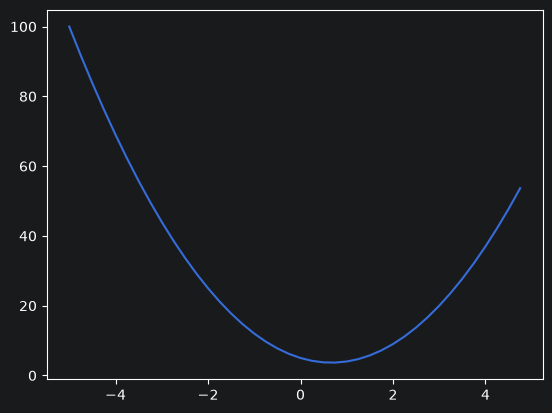

In [112]:
# Around x=3, the curve is rising as x moves right.
# That visual rise is why we expect the derivative there to be positive.
# The plot shows the shape of f(x).
# Slope means the local tilt of this curve at one specific x value.
plt.plot(xs, ys)

## 5. Estimate a derivative numerically

A **derivative** is local sensitivity: how much the output changes when the input changes a tiny bit. Here we estimate it by nudging `x` by `h` and measuring `rise / run`.

In [113]:
# Smaller h usually makes the estimate more local.
# If h gets too tiny, floating point rounding can start to pollute the result.
# h is a tiny positive nudge to the input.
# x is the point where we want to estimate the slope.
h = 0.001
x = 3.0

# Compare the original output with the output after nudging x upward by h.
f(x), f(x + h)

(20.0, 20.014003000000002)

In [114]:
# If this number is positive, increasing x increases f(x) locally.
# If this number is negative, increasing x decreases f(x) locally.
# For this function, the exact derivative is 6*x - 4, which equals 14 when x=3.
# Numerical derivative = rise / run.
# rise: how much the output changed, f(x + h) - f(x)
# run: how much the input changed, h
(f(x + h) - f(x)) / h

14.00300000000243

In [115]:
# Try the same slope estimate at a negative x value.
# Here the curve is falling as x moves right, so the derivative should be negative.
x = -3.0
(f(x + h) - f(x)) / h

-21.996999999998934

In [116]:
# Try the point near the bottom of the parabola.
# At the minimum, the curve is almost flat, so the derivative should be near zero.
x = 2 / 3
(f(x + h) - f(x)) / h

0.0029999999995311555

## 6. Move from one input to several inputs

Now the output `d` depends on three inputs: `a`, `b`, and `c`. This is closer to neural networks, where a final number such as a loss depends on many weights.

In [117]:
# A slightly more complex expression with three input numbers.
# d depends on a, b, and c through multiplication first, then addition.
# Python follows normal precedence here: a * b happens before + c.
a = 2.0
b = -3.0
c = 10.0

# Forward pass: compute the output value from the current inputs.
d = a * b + c
print(d)

4.0


## 7. Measure how `a` influences `d`

Here we keep `b` and `c` fixed, nudge only `a`, and recompute `d`. This estimates the partial derivative of `d` with respect to `a`, meaning the local influence of `a` alone.

In [118]:
# Estimate the partial derivative of d with respect to a.
# Partial derivative means: change one input while holding the others fixed.
h = 0.0001

# Original inputs.
a = 2.0
b = -3.0
c = 10.0

# First forward pass: output before the nudge.
d1 = a * b + c
print(d1)

# Nudge only a. b and c stay the same.
a += h

# Second forward pass: output after the nudge.
d2 = a * b + c
print(d2)

# rise / run estimates how sensitive d is to a at this point.
# Since b is -3, increasing a makes a*b smaller, so this slope is negative.
print(f"Slope: {d2 - d1} / {h} = {(d2 - d1) / h}")

4.0
3.999699999999999
Slope: -0.0003000000000010772 / 0.0001 = -3.000000000010772


## 8. Measure how `b` influences `d`

Now we keep `a` and `c` fixed, nudge only `b`, and recompute `d`. Comparing this with the previous cell shows that each input can have its own separate influence on the same output.

In [119]:
# Estimate the partial derivative of d with respect to b.
# This time a and c are held fixed, and only b gets nudged.
h = 0.0001

# Original inputs.
a = 2.0
b = -3.0
c = 10.0

# First forward pass: output before the nudge.
d1 = a * b + c
print(d1)

# Nudge only b. a and c stay the same.
b += h

# Second forward pass: output after the nudge.
d2 = a * b + c
print(d2)

# Because a is 2, increasing b increases a*b at about 2 times the nudge.
print(f"Slope: {d2 - d1} / {h} = {(d2 - d1) / h}")

4.0
4.0002
Slope: 0.00020000000000042206 / 0.0001 = 2.0000000000042206


## What this unlocks

You have now measured influence in two settings: one input into one output, and several inputs into one output. Backpropagation uses the same idea, but it stores each local influence and combines them through a computation graph.

## 9. Wrap scalar numbers in a `Value` object

A `Value` is a small container around one number. Besides the raw number, it remembers which earlier `Value` objects produced it, which operation connected them, and an optional human-readable label. That memory is the beginning of a computation graph.

In [120]:
# Value is the core data structure of micrograd.
# It stores one scalar number plus just enough history to remember how it was created.
class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        # data is the actual scalar number, like 2.0 or -3.0.
        self.data = data

        # _prev stores the previous Value objects that produced this one.
        # A set avoids duplicate references and makes graph traversal easier later.
        self._prev = set(_children)

        # _op stores the operation string, such as '+' or '*'.
        # This is only for understanding/debugging the graph right now.
        self._op = _op

        # label is a human-friendly name like "a", "b", "c", or "d".
        # It is not needed for math, but it makes graph drawings readable.
        self.label = label

    def __repr__(self):
        # This controls how a Value prints in the notebook.
        return f"Value(data={self.data})"

    def __add__(self, other):
        # Python calls this method when we write self + other.
        # The output value remembers both inputs and that '+' created it.
        out = Value(self.data + other.data, (self, other), "+")
        return out

    def __mul__(self, other):
        # Python calls this method when we write self * other.
        # The output value remembers both inputs and that '*' created it.
        out = Value(self.data * other.data, (self, other), "*")
        return out

## 10. Rebuild the expression using `Value` objects

This repeats `d = a * b + c`, but now each intermediate result is a `Value`. The final answer is still `4.0`, but the objects also carry graph structure that plain Python floats do not store.

In [121]:
# Create leaf Value objects.
# Leaf means they are starting inputs, not results of earlier operations.
# Labels make the graph visualization easier to read.
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")

# Build the intermediate product explicitly so we can label it.
# e is the Value produced by the multiplication node a * b.
e = a * b
e.label = "e"

# Reuse normal Python syntax.
# Under the hood, this calls Value.__mul__ first, then Value.__add__.
d = e + c
d.label = "d"

# The printed result shows the forward-pass number stored in d.data.
d


f = Value(-2.0, label="f")
L = d*f; L.label = "L"
L

Value(data=-8.0)

## 11. Inspect the graph connection

`d._prev` shows the immediate parent values that fed into `d`, and `d._op` shows the operation that created `d`. This is how Micrograd knows where to send gradient information later during backpropagation.

In [122]:
# d was created by adding two parent Values:
# 1. the intermediate Value from a * b, which has data -6.0
# 2. c, which has data 10.0
# The operation that created d is '+'.
d._prev, d._op

({Value(data=-6.0), Value(data=10.0)}, '+')

## 12. Add graph visualization helpers

The `Value` objects already remember their parents, but sets and object IDs are hard to read directly. These helper functions walk backward from a final value and ask Graphviz to draw the computation graph.

In [123]:
# Graphviz draws the computation graph as boxes and arrows.
# If this import fails, install the Python package and the Graphviz system binary.
from graphviz import Digraph


def trace(root):
    # Build two sets:
    # - nodes: every Value reachable from root
    # - edges: parent -> child relationships between Values
    nodes, edges = set(), set()

    def build(v):
        # Visit each Value once so recursive graph traversal terminates.
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                # child produced v through v._op, so draw an edge child -> v.
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    # rankdir="LR" asks Graphviz to lay the graph out from left to right.
    dot = Digraph(format="svg", graph_attr={"rankdir": "LR"})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))

        # Create a rectangular node for each Value.
        # The label shows the human name and the current forward-pass data.
        dot.node(name=uid, label=f" {n.label} | {{ data {n.data:.4f} }}", shape="record")

        if n._op:
            # Operation nodes are separate circles/ellipses like '*' and '+'.
            # This makes it visually clear which operation produced each Value.
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # Connect each parent Value to the operation that produced its child Value.
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

## 13. Draw the expression graph

This picture makes the hidden structure visible: `a` and `b` feed into `*`, the result `e` feeds into `+` with `c`, and the final output is `d`. Later, gradients will flow backward along the same arrows.

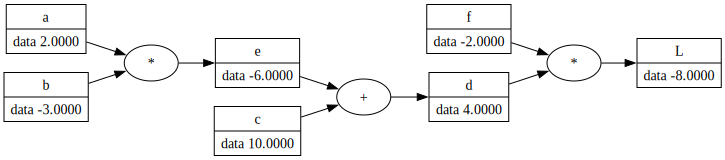

In [124]:
# Draw the graph ending at d.
# Read it left to right: a and b multiply into e, then e and c add into d.
draw_dot(L)

## What this unlocks next

The graph now shows both the forward values and the dependency path from inputs to output. The next missing piece is a `grad` field plus backward rules, so each `Value` can learn how much it influenced the final output.